##Setup and Loading

In [1]:
#Connect google drive for file access
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#Import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

# Suppress non-critical warnings to keep output readable
warnings.filterwarnings('ignore')

Mounted at /content/drive


This part connects my Google Drive to Google Colab and sets up the folder structure for the project. It helps keep all the raw data (house prices, crime, and geography), processed datasets, and output stored in the right places, making it easier to reproduce the analysis later.



##Setup my file paths

In [ ]:
BASE_PATH             = Path('/content/drive/My Drive/Bristol_Project')

#RAW_PATH 
house_prices_raw_path = BASE_PATH / 'data' / 'raw' / 'house_prices'
crime_raw_path        = BASE_PATH / 'data' / 'raw' / 'crime'
geo_path              = BASE_PATH / "data" / "raw" / "geo"
processed_data_path   = BASE_PATH / 'data' / 'processed'
output_path           = BASE_PATH / 'output'

# Create directories if they don't exist
processed_data_path.mkdir(parents=True, exist_ok=True)
output_path.mkdir(parents=True, exist_ok=True)

I also create processed and output folders at the start so that cleaned datasets and figures are automatically saved for later analysis.

#Analysis parameters

In [3]:
config = {
    #scope
    'start_year' : 2021,
    'end_year' : 2024,

    #geographic identifiers
    'bristol_postcode_prefix': 'BS',
    'bristol_lsoa_prefix': 'E01014',  # Bristol LSOA codes
    'bristol_district': 'CITY OF BRISTOL',

    # Geographic extent
    'lat_min': 51.42,
    'lat_max': 51.50,
    'lon_min': -2.649,
    'lon_max': -2.530,

    # Statistical thresholds
    'significance_level': 0.05,  # For hypothesis tests
    'iqr_multiplier': 1.5,

    # GWR model settings
    'gwr_kernel': 'bisquare',
    'gwr_adaptive': True,

}

print(f" Base path - {BASE_PATH}")
print(f" Analysis period - {config['start_year']}-{config['end_year']}")
print(f" Geographic scope - Bristol ({config['bristol_district']})")

 Base path - /content/drive/My Drive/Bristol_Project
 Analysis period - 2021-2024
 Geographic scope - Bristol (CITY OF BRISTOL)


I focus the data on Bristol by filtering with both postcode and LSOA prefixes, along with a latitude and longitude bounding box.
To handle outliers, I apply the standard 1.5×IQR rule, a common statistical method that removes extreme and unrepresentative house prices while keeping most of the Bristol housing market data. I also set the significance level to 5% for all hypothesis tests to stay consistent with the project proposal. Finally, I configure the GWR model to use an adaptive bisquare kernel, which gives more weight to nearby LSOAs and less to those farther away, keeping a similar number of neighbours for each local regression.



#Library import

In [4]:
import pandas as pd
import numpy as np

# Spatial analysis
import geopandas as gpd
from shapely.geometry import Point

# Statistical analysisy
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Spatial econometrics
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

# Spatial statistics (for Moran's I)
try:
    from esda.moran import Moran
    from libpysal.weights import Queen, KNN
    SPATIAL_STATS_AVAILABLE = True
except ImportError:
    print("  Warning: PySAL not available.")
    SPATIAL_STATS_AVAILABLE = False

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


# Interactive maps
try:
    import folium
    FOLIUM_AVAILABLE = True
except ImportError:
    print("  Warning: Folium not available.")
    FOLIUM_AVAILABLE = False


#Data Loading Functions

In [5]:
def load_house_price_data(data_path, start_year=2021, end_year=2024):
    """
    Load and concatenate HM Land Registry house price data for Bristol.

    Parameters
    ----------
    data_path : Path
        Folder containing raw price-paid CSV files (e.g. pp-2021.csv).
    start_year : int
        First year.
    end_year : int
        Last year.

    Returns
    -------
    pd.DataFrame
        Combined house price dataset filtered to the chosen years.
    """
    print(f"(1) Loading house price data from {data_path}...")

    column_names = [
        'transaction_id', 'price', 'date', 'postcode', 'property_type',
        'new_build_flag', 'tenure_type', 'paon', 'saon', 'street',
        'locality', 'town_city', 'district', 'county',
        'ppd_category', 'record_status'
    ]

    csv_files = list(data_path.glob("pp-*.csv"))
    if len(csv_files) == 0:
        raise FileNotFoundError(
            f"     No house price files found in {data_path}. "
            f"     Expected format: pp-YYYY.csv"
        )

    print(f"     Found {len(csv_files)} CSV files")

    dataframes = []
    for file in csv_files:
        try:
            df = pd.read_csv(
                file,
                header=None,
                names=column_names,
                low_memory=False
            )
            dataframes.append(df)
        except Exception as e:
            print(f"     Error loading {file.name}: {e}")
            continue

    if len(dataframes) == 0:
        raise ValueError("     No valid house price data loaded")

    house_data = pd.concat(dataframes, ignore_index=True)

    house_data['date'] = pd.to_datetime(house_data['date'], errors='coerce')
    house_data['year'] = house_data['date'].dt.year

    house_data = house_data[
        (house_data['year'] >= start_year) &
        (house_data['year'] <= end_year)
    ].copy()

    print(f"     Loaded {len(house_data):,} transactions ({start_year}-{end_year})")
    print(f"     Date range: {house_data['date'].min()} to {house_data['date'].max()}")
    print(" ")

    return house_data


def load_crime_data(data_path, start_year=2021, end_year=2024):
    """
    Load and concatenate monthly Police.uk crime data for Bristol.

    Parameters
    ----------
    data_path : Path
        Folder containing raw monthly crime CSV files.
    start_year : int
        First year to include in the analysis.
    end_year : int
        Last year to include in the analysis.

    Returns
    -------
    pd.DataFrame
        Combined crime dataset filtered to the chosen years.
    """
    print(f"(2) Loading crime data from {data_path}...")

    csv_files = list(data_path.rglob("*.csv"))
    if len(csv_files) == 0:
        raise FileNotFoundError(f"     No crime files found in {data_path}")

    print(f"     Found {len(csv_files)} CSV files")

    dataframes = []
    for file in csv_files:
        try:
            df = pd.read_csv(file, low_memory=False)
            dataframes.append(df)
        except Exception as e:
            print(f"     Error loading {file.name}: {e}")
            continue

    if len(dataframes) == 0:
        raise ValueError("     No valid crime data loaded")

    crime_data = pd.concat(dataframes, ignore_index=True)

    crime_data['Month'] = pd.to_datetime(crime_data['Month'], errors='coerce')
    crime_data['year'] = crime_data['Month'].dt.year

    crime_data = crime_data[
        (crime_data['year'] >= start_year) &
        (crime_data['year'] <= end_year)
    ].copy()

    print(f"     Loaded {len(crime_data):,} crime records ({start_year}-{end_year})")
    print(f"     Unique crime types: {crime_data['Crime type'].nunique()}")
    print(" ")

    return crime_data


def load_geospatial_data(geo_path):
    """
    Load LSOA boundary polygons and a postcode-to-LSOA lookup table.

    Parameters
    ----------
    geo_path : Path
        Folder containing the LSOA shapefile and postcode directory CSV.

    Returns
    -------
    gpd.GeoDataFrame
        LSOA boundary geometries with standardised code/name columns.
    pd.DataFrame
        Postcode-to-LSOA lookup table with standardised column names.
    """
    print(f"(3) Loading geospatial data from {geo_path}...")

    # 1) LSOA boundaries
    lsoa_shp_files = list(
        geo_path.rglob("Lower_Layer_Super_Output_Areas_2021_(Precise).shp")
    )
    if len(lsoa_shp_files) == 0:
        lsoa_shp_files = list(geo_path.rglob("*.shp"))

    if len(lsoa_shp_files) == 0:
        raise FileNotFoundError(
            f"     No LSOA shapefile found under {geo_path}. "
            f"     Expected something like Lower_Layer_Super_Output_Areas_2021_(Precise).shp"
        )

    lsoa_file = lsoa_shp_files[0]
    print(f"     Using LSOA file: {lsoa_file}")

    lsoa_gdf = gpd.read_file(lsoa_file)

    # Standardise column names
    lsoa_column_mappings = {
        'LSOA21CD': 'lsoa_code',
        'LSOA Code': 'lsoa_code',
        'lsoa21cd': 'lsoa_code',
        'LSOA21NM': 'lsoa_name',
        'LSOA Name': 'lsoa_name',
    }

    for old_col, new_col in lsoa_column_mappings.items():
        if old_col in lsoa_gdf.columns:
            lsoa_gdf = lsoa_gdf.rename(columns={old_col: new_col})

    print(f"     Loaded {len(lsoa_gdf)} LSOA polygons")

    # 2) Postcode-to-LSOA lookup
    postcode_files = list(geo_path.glob("postcode_directory_*.csv"))
    if len(postcode_files) == 0:
        raise FileNotFoundError(
            f"     No postcode lookup file found in {geo_path}. "
            f"     Expected: postcode_directory_*.csv"
        )

    postcode_file = postcode_files[0]
    print(f"     Using postcode file: {postcode_file}")

    postcode_df = pd.read_csv(postcode_file, low_memory=False)

    postcode_column_mappings = {
        'pcds': 'postcode',
        'Postcode': 'postcode',
        'lsoa21cd': 'lsoa_code',
        'LSOA Code': 'lsoa_code',
    }

    for old_col, new_col in postcode_column_mappings.items():
        if old_col in postcode_df.columns:
            postcode_df = postcode_df.rename(columns={old_col: new_col})

    print(f"     Loaded {len(postcode_df):,} postcode-to-LSOA mappings...")
    print(" ")

    return lsoa_gdf, postcode_df


In this step, I load the three main datasets used in my project: HM Land Registry price-paid data, monthly Police.uk crime data, and geospatial files for Bristol’s LSOAs and postcodes. The loading function combine them, filter to match my analysis period. The geospatial function also standardises the column names for LSOA codes, LSOA names, and postcodes, since the original files use slightly different labels.

#Data cleaning functions

House data

In [6]:
def clean_house_prices(house_data, config):
    """
    Clean and filter house price data for Bristol.

    Cleaning steps
    --------------
    1. Filter to the Bristol local authority district.
    2. Standardise price and postcode formats.
    3. Drop rows with missing values in critical fields.
    4. Remove clearly invalid prices (< £100).
    5. Remove extreme outliers using the IQR method (proposal requirement).

    Parameters
    ----------
    house_data : pd.DataFrame
        Raw house price data loaded from HM Land Registry.
    config : dict
        Project configuration dictionary (includes Bristol district name and
        IQR multiplier).

    Returns
    -------
    pd.DataFrame
        Cleaned house price data for Bristol, ready for aggregation.
    """
    print("(1) Cleaning house price data...")

    df = house_data.copy()
    initial_count = len(df)

    # 1) Filter for Bristol district
    df = df[df['district'].str.upper() == config['bristol_district']].copy()
    print(f"     Filtered to {config['bristol_district']}: {len(df):,} records")

    # 2) Standardise price and postcode
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['postcode'] = df['postcode'].astype(str).str.strip().str.upper()

    # 3) Remove rows with missing critical fields
    required_fields = ['price', 'date', 'postcode', 'property_type']
    before_missing = len(df)
    df = df.dropna(subset=required_fields)
    print(f"     Removed {before_missing - len(df):,} rows with missing data")

    # 4) Remove clearly invalid prices
    df = df[df['price'] >= 100]

    # 5) Remove outliers using the IQR rule
    Q1 = df['price'].quantile(0.25)
    Q3 = df['price'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - config['iqr_multiplier'] * IQR
    upper_bound = Q3 + config['iqr_multiplier'] * IQR

    before_outlier = len(df)
    df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

    print(f"       - Removed {before_outlier - len(df):,} outliers (IQR method)")
    print(f"       - Price range: £{df['price'].min():,.0f} - £{df['price'].max():,.0f}")
    print(f"       - Median price: £{df['price'].median():,.0f}")

    # Summary of how aggressive the cleaning was
    retention_rate = len(df) / initial_count * 100
    print(f"     Final: {len(df):,} records ({retention_rate:.1f}% retained)")
    print(" ")

    return df


In this step, I filter the raw HM Land Registry data to include only records from the Bristol local authority area. I then standardise the price and postcode formats and remove any rows with missing values in key fields such as price, date, postcode, or property type. To handle outliers, I remove obviously incorrect prices (below £100) and then apply the standard 1.5×IQR rule to exclude only the most extreme values. After cleaning, I summarise how many transactions remain and report the price range and median to make sure the cleaning process isn’t too harsh.

Crime data

In [7]:
def clean_crime_data(crime_data, config):
    """
    Clean and filter Police.uk crime data for Bristol.

    Cleaning steps
    --------------
    1. Filter by LSOA code (Bristol codes start with E01014).
    2. Convert latitude/longitude to numeric and apply a Bristol bounding box.
    3. Drop records with missing key fields.
    4. Remove duplicate records.
    5. Standardise the LSOA code column name.

    Parameters
    ----------
    crime_data : pd.DataFrame
        Raw crime data loaded from Police.uk.
    config : dict
        Project configuration with Bristol LSOA prefix and geographic bounds.

    Returns
    -------
    pd.DataFrame
        Cleaned crime data for Bristol LSOAs.
    """
    print("(2) Cleaning crime data...")

    df = crime_data.copy()
    initial_count = len(df)

    # 1) Filter for Bristol LSOA codes
    df = df[
        df['LSOA code'].astype(str).str.startswith(
            config['bristol_lsoa_prefix'], na=False
        )
    ].copy()
    print(f"     Filtered to Bristol LSOA codes: {len(df):,} records")

    # 2) Convert coordinates to numeric
    df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
    df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

    # 3) Filter by geographic extent
    before_geo = len(df)
    df = df[
        (df['Latitude'] >= config['lat_min']) &
        (df['Latitude'] <= config['lat_max']) &
        (df['Longitude'] >= config['lon_min']) &
        (df['Longitude'] <= config['lon_max'])
    ]
    print(f"     Geographic filtering: {before_geo - len(df):,} records removed")

    # 4) Remove records with missing important fields
    required_fields = ['Month', 'Crime type', 'LSOA code', 'Latitude', 'Longitude']
    before_missing = len(df)
    df = df.dropna(subset=required_fields)
    print(f"       - Removed {before_missing - len(df):,} rows with missing data")

    # 5) Remove duplicates
    before_dup = len(df)
    df = df.drop_duplicates()
    print(f"       - Removed {before_dup - len(df):,} duplicate records")

    # 6) Rename for consistency
    df = df.rename(columns={'LSOA code': 'lsoa_code'})

    # Summary
    retention_rate = len(df) / initial_count * 100
    print(f"     Final: {len(df):,} records ({retention_rate:.1f}% retained)")
    print(f"     Unique LSOAs: {df['lsoa_code'].nunique()}")
    print(f"     Unique crime types: {df['Crime type'].nunique()}")
    print(" ")

    return df


First, I keep only the records with LSOA codes starting with “E01014”, which correspond to the Bristol area. I also drop rows with missing values in key fields such as date, crime type, LSOA code, or coordinates, and remove exact duplicates. After cleaning, I record how many entries remain and check how many distinct LSOAs and crime categories are included, to confirm that the dataset is ready for neighbourhood-level spatial analysis.

#Aggregation & Merging Functions

House data

In [8]:
def aggregate_house_prices_by_lsoa(house_clean, postcode_lookup):
    """
    Aggregate cleaned house price data to LSOA level.

    The function links each transaction to an LSOA using the postcode
    directory, then computes for each LSOA:
    - median sale price
    - mean sale price
    - number of sales
    - proportion of flats
    - proportion of leasehold properties

    Parameters
    ----------
    house_clean : pd.DataFrame
        Cleaned house price data.
    postcode_lookup : pd.DataFrame
        Postcode-to-LSOA mapping table.

    Returns
    -------
    pd.DataFrame
        LSOA-level house price statistics.
    """
    # Standardise postcode format in both datasets
    house_clean['postcode_clean'] = (
        house_clean['postcode'].astype(str).str.strip().str.upper()
    )
    postcode_lookup['postcode_clean'] = (
        postcode_lookup['postcode'].astype(str).str.strip().str.upper()
    )

    # Merge house data with LSOA codes
    house_lsoa = house_clean.merge(
        postcode_lookup[['postcode_clean', 'lsoa_code']],
        on='postcode_clean',
        how='left'
    )

    # Check merge success
    merge_rate = house_lsoa['lsoa_code'].notna().sum() / len(house_lsoa) * 100
    print("(1) Aggregate House Price by LSOA")
    print(" ")
    print(f"     Matched {merge_rate:.1f}% of house records to LSOA codes")

    # Drop unmatched records
    house_lsoa = house_lsoa.dropna(subset=['lsoa_code'])

    # Create indicator variables for property type and tenure
    house_lsoa['is_flat'] = (house_lsoa['property_type'] == 'F').astype(int)
    house_lsoa['is_leasehold'] = (house_lsoa['tenure_type'] == 'L').astype(int)

    # Aggregate to LSOA level
    lsoa_agg = house_lsoa.groupby('lsoa_code').agg(
        median_price=('price', 'median'),
        mean_price=('price', 'mean'),
        n_sales=('price', 'size'),
        flat_count=('is_flat', 'sum'),
        leasehold_count=('is_leasehold', 'sum')
    ).reset_index()

    # Calculate proportions
    lsoa_agg['prop_flats'] = lsoa_agg['flat_count'] / lsoa_agg['n_sales']
    lsoa_agg['prop_leasehold'] = (
        lsoa_agg['leasehold_count'] / lsoa_agg['n_sales']
    )

    print(f"     Aggregated to {len(lsoa_agg)} LSOAs")
    print(f"     Mean sales per LSOA: {lsoa_agg['n_sales'].mean():.1f}")

    return lsoa_agg


I first standardise postcodes in both the cleaned Land Registry data and the postcode directory, then merge them so that each transaction is linked to its corresponding LSOA code. After checking the match rate and removing any unmatched records, I group the data by LSOA to calculate the median and mean sale prices, total number of transactions, and counts of flats and leasehold properties. From these, I compute the proportion of flats and leasehold sales within each LSOA. This creates a concise dataset summarising key housing market characteristics for every neighbourhood.

Crime data

In [9]:
def aggregate_crime_by_lsoa(crime_clean):
    """
    Aggregate crime counts to LSOA level.

    Parameters
    ----------
    crime_clean : pd.DataFrame
        Cleaned crime data with an `lsoa_code` column.

    Returns
    -------
    pd.DataFrame
        LSOA-level crime counts with one row per LSOA and a
        `total_crimes` column.
    """
    crime_agg = (
        crime_clean
        .groupby('lsoa_code')
        .size()
        .reset_index(name='total_crimes')
    )

    print(" ")
    print("(2) Aggregate Crime by LSOA")
    print(" ")
    print(f"     Aggregated to {len(crime_agg)} LSOAs")
    print(f"     Mean crimes per LSOA: {crime_agg['total_crimes'].mean():.1f}")
    print(f"     Range: {crime_agg['total_crimes'].min()} - {crime_agg['total_crimes'].max()}")

    return crime_agg


I aggregate crime incidents to match the LSOA geography used for the house price data. I group the records by lsoa_code and count how many incidents occur in each area to create a total_crimes variable for every neighbourhood. I then summarise the data by reporting how many LSOAs are covered, along with the average, minimum, and maximum number of crimes per LSOA. This step transforms individual crime points into an LSOA-level measure of crime intensity.

#Regression dataset

In [10]:
def create_regression_dataset(lsoa_house, lsoa_crime, lsoa_gdf):
    """
    Merge house price, crime, and spatial data into the final regression dataset.

    Parameters
    ----------
    lsoa_house : pd.DataFrame
        LSOA-level house price statistics (median price, n_sales, proportions).
    lsoa_crime : pd.DataFrame
        LSOA-level crime counts (total_crimes).
    lsoa_gdf : gpd.GeoDataFrame
        LSOA boundary polygons for Bristol.

    Returns
    -------
    gpd.GeoDataFrame
        Complete dataset for regression and GWR, including geometry and
        log-transformed variables.
    """
    # Merge house prices and crime counts
    reg_df = lsoa_house.merge(lsoa_crime, on='lsoa_code', how='inner')
    print(" ")
    print(f"After merging house + crime: {len(reg_df)} LSOAs")

    # Ensure LSOA code column name in spatial data is standardised
    if 'lsoa_code' not in lsoa_gdf.columns:
        for col in ['LSOA21CD', 'lsoa21cd', 'LSOA Code']:
            if col in lsoa_gdf.columns:
                lsoa_gdf = lsoa_gdf.rename(columns={col: 'lsoa_code'})
                break

    # Merge with spatial geometries
    reg_gdf = lsoa_gdf.merge(reg_df, on='lsoa_code', how='inner')
    print(f"After merging with spatial data: {len(reg_gdf)} LSOAs")

    # Add log-transformed variables for linear modelling
    reg_gdf['log_median_price'] = np.log(reg_gdf['median_price'])
    reg_gdf['log_crime'] = np.log(reg_gdf['total_crimes'] + 1)  # +1 to avoid log(0)

    # Drop any remaining missing values in key predictors
    before_drop = len(reg_gdf)
    reg_gdf = reg_gdf.dropna(subset=[
        'log_median_price', 'log_crime', 'prop_flats', 'prop_leasehold'
    ])

    if before_drop > len(reg_gdf):
        print(f"Dropped {before_drop - len(reg_gdf)} LSOAs with missing values")

    print(f"Final dataset: {len(reg_gdf)} LSOAs ready for analysis")

    return reg_gdf


To prepare the data for modelling, I combine the house price, crime, and spatial information into a single LSOA-level dataset. I start by merging the LSOA-level house price statistics with the corresponding crime counts using the shared lsoa_code column.

I then join this merged table with the Bristol LSOA boundary polygons so that each record includes its geographic shape, which is needed for mapping and GWR analysis. Next, I create log-transformed versions of the median price and total crime variables to make the relationships more linear and to interpret coefficients in percentage terms rather than raw values.

Finally, I remove any LSOAs with missing data in important variables such as prop_flats or prop_leasehold. The outcome is a clean GeoDataFrame containing one row per LSOA, ready for the correlation, OLS regression, and GWR modelling steps.

#Statistical testing functions

In [11]:
def test_correlation(df, var1, var2, alpha=0.05):
    """
    Perform Pearson and Spearman correlation tests.

    Parameters
    ----------
    df : pd.DataFrame
    var1, var2 : str
        Column names to correlate
    alpha : float
        Significance level (default 0.05)

    Returns
    -------
    dict
        Correlation results with statistical significance
    """
    # Pearson correlation (assumes linear relationship)
    r_pearson, p_pearson = pearsonr(df[var1], df[var2])

    # Spearman correlation (non-parametric, rank-based)
    r_spearman, p_spearman = spearmanr(df[var1], df[var2])

    results = {
        'pearson_r': r_pearson,
        'pearson_p': p_pearson,
        'pearson_sig': p_pearson < alpha,
        'spearman_r': r_spearman,
        'spearman_p': p_spearman,
        'spearman_sig': p_spearman < alpha,
    }

    return results

def print_correlation_results(results, var1, var2):
    print("Statistical Testing")
    print(" ")
    print(f"(1) Correlation Analysis: {var1} vs {var2}")
    print(f"     Pearson r = {results['pearson_r']:.4f}, p = {results['pearson_p']:.4f} " +
          f"{' --> Significant' if results['pearson_sig'] else '✗ Not significant'}")

    print(f"     Spearman ρ = {results['spearman_r']:.4f}, p = {results['spearman_p']:.4f} " +
          f"{' --> Significant' if results['spearman_sig'] else '✗ Not significant'}")

Before running the regression models, I explore the relationship between crime and house prices. Pearson’s correlation measures the strength of linear relationships, while Spearman’s correlation is rank-based and less sensitive to skewed data or outliers. For each variable pair (for instance, log crime and log median price), I calculate the correlation coefficients and corresponding p‑values, then compare them against a 5% significance level.


In [12]:
def perform_statistical_tests(reg_gdf, config):
    """
    Comprehensive statistical testing as per project proposal.

    Tests:
    1. Correlation between crime and house prices
    2. Hypothesis test: Do high-crime areas have lower prices?

    Parameters
    ----------
    reg_gdf : gpd.GeoDataFrame
        Regression dataset
    config : dict
        Configuration with significance level

    Returns
    -------
    dict
        All test results
    """

    alpha = config['significance_level']

    # Test 1: Correlation between log_crime and log_median_price
    corr_results = test_correlation(reg_gdf, 'log_crime', 'log_median_price', alpha = alpha)

    print_correlation_results(corr_results, 'log(Crime)', 'log(Price)')

    # Test 2: Compare high-crime vs low-crime areas

    # Split at median crime level
    median_crime = reg_gdf['total_crimes'].median()
    high_crime = reg_gdf[reg_gdf['total_crimes'] > median_crime]['log_median_price']
    low_crime = reg_gdf[reg_gdf['total_crimes'] <= median_crime]['log_median_price']

    # Independent t-test
    t_stat, p_value = ttest_ind(high_crime, low_crime)

    print(f"(2) Hypothesis Test: High-Crime vs Low-Crime Areas")
    print(f"     H0: Mean log(price) is equal in high and low crime areas")
    print(f"     H1: Mean log(price) differs between high and low crime areas")
    print(" ")
    print(f"     t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")


    if p_value < alpha:
        print(f"Result: REJECT H0 (p < {alpha})")
        print(f"Interpretation: Statistically significant difference in prices")
        mean_diff = high_crime.mean() - low_crime.mean()
        pct_diff = (np.exp(mean_diff) - 1) * 100
        print(f"High-crime areas are ~{pct_diff:.1f}% {'higher' if pct_diff > 0 else 'lower'} priced")
    else:
        print(f"Result: FAIL TO REJECT H0 (p >= {alpha})")
        print(f"Interpretation: No statistically significant difference")


        # Store results
    test_results = {
        'correlation': corr_results,
        't_test': {
            't_statistic': t_stat,
            'p_value': p_value,
            'significant': p_value < alpha,
            'high_crime_mean': high_crime.mean(),
            'low_crime_mean': low_crime.mean(),
        }
    }

    return test_results


Using the regression dataset, I calculate both Pearson and Spearman correlations between the log of total crimes and the log of median house prices, reporting the correlation coefficients and p‑values at a 5% significance level. This indicates whether higher crime levels are generally linked to higher or lower prices on average.

Next, I divide the LSOAs into “high-crime” and “low-crime” groups based on the median total crime count and run an independent samples t‑test on the log of median prices. I did hypothesis test to address the proposal’s question about whether high-crime neighbourhoods are statistically significantly less expensive than low-crime ones

#Regression Modelling Functions

In [13]:
def fit_ols_model(reg_gdf):
    """
    Fit global OLS regression model (baseline for comparison).

    Model: log(price) ~ log(crime) + prop_flats + prop_leasehold

    The model provides a single 'average' relationship for all Bristol LSOAs
    and acts as a baseline to compare with the GWR model.
    """
    print(" ")
    print("(1) ORDINARY LEAST SQUARES (OLS) REGRESSION - GLOBAL MODEL")

    # Prepare data
    y = reg_gdf['log_median_price'].values            # shape (n,)
    X = reg_gdf[['log_crime', 'prop_flats', 'prop_leasehold']].values  # shape (n, 3)

    # Fit OLS
    ols = LinearRegression()
    ols.fit(X, y)

    # Predictions and residuals
    y_pred = ols.predict(X)
    residuals = y - y_pred

    # Metrics
    r2 = r2_score(y, y_pred)
    n = len(y)
    k = X.shape[1] + 1          # 3 predictors + intercept

    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k)

    mse = mean_squared_error(y, y_pred)
    rss = np.sum(residuals ** 2)
    aic = n * np.log(rss / n) + 2 * k
    aicc = aic + (2 * k * (k + 1)) / (n - k - 1)

    print("\nModel: log(price) = β0 + β1·log(crime) + β2·prop_flats + β3·prop_leasehold")

    print("\nCoefficients:")
    print(f"   Intercept:       {ols.intercept_:.4f}")
    print(f"   log(crime):      {ols.coef_[0]:.4f}")
    print(f"   prop_flats:      {ols.coef_[1]:.4f}")
    print(f"   prop_leasehold:  {ols.coef_[2]:.4f}")

    print("\nModel Fit:")
    print(f"   R²:              {r2:.4f}")
    print(f"   Adjusted R²:     {adj_r2:.4f}")
    print(f"   AIC:             {aic:.2f}")
    print(f"   AICc:            {aicc:.2f}")
    print(f"   RMSE:            {np.sqrt(mse):.4f}")

    # Interpretation of crime effect (global)
    crime_effect_pct = (np.exp(ols.coef_[0]) - 1) * 100
    print(f"\nInterpretation: A 1-unit increase in log(crime) ≈ {crime_effect_pct:.2f}% change in price")

    return {
        "model": ols,
        "y_pred": y_pred,
        "residuals": residuals,
        "r2": r2,
        "adj_r2": adj_r2,
        "aic": aic,
        "aicc": aicc,
        "rmse": float(np.sqrt(mse)),
        "coefficients": {
            "intercept": float(ols.intercept_),
            "log_crime": float(ols.coef_[0]),
            "prop_flats": float(ols.coef_[1]),
            "prop_leasehold": float(ols.coef_[2]),
        },

    }

I fit a global Ordinary Least Squares regression where log median house price is explained by log total crimes, the proportion of flats, and the proportion of leasehold properties in each LSOA. This model assumes that the effect of crime and housing composition on prices is the same everywhere in Bristol. I also convert the coefficient on log crime into an approximate percentage change in price, so I can quantify how much prices change when crime increases. In later sections I compare these global results to the GWR model to see whether allowing the crime effect to vary by location gives a better fit.

In [14]:
def fit_gwr_model(reg_gdf, config):
    """
    Fit a Geographically Weighted Regression (GWR) model.

    Model
    -----
    log(median_price) ~ log(crime) + prop_flats + prop_leasehold

    GWR allows the regression coefficients to vary across space, so each
    LSOA has its own local crime and housing composition effects. This
    model is used to capture spatial heterogeneity and to compare against
    the global OLS baseline.
    """
    print(" ")
    print("(3) GEOGRAPHICALLY WEIGHTED REGRESSION (GWR)")
    print(" ")

    # Extract centroid coordinates for each LSOA
    coords = np.column_stack([
        reg_gdf.geometry.centroid.x,
        reg_gdf.geometry.centroid.y
    ])

    # Outcome and predictors
    y = reg_gdf['log_median_price'].values.reshape(-1, 1)  # keep 2D
    X = reg_gdf[['log_crime', 'prop_flats', 'prop_leasehold']].values

    print(f"Input shape: coords={coords.shape}, y={y.shape}, X={X.shape}")

    # Basic sample size check
    if len(reg_gdf) < 30:
        print("Too few LSOAs for a stable GWR fit.")
        return None

    # Bandwidth selection
    print("Bandwidth selection...")
    try:
        bw = Sel_BW(coords, y, X).search()
        print(f"    Bandwidth: {bw:.1f}")
    except Exception:
        print("    Bandwidth selection failed - using fixed fallback value.")
        bw = 50  # adaptive fallback

    # Fit GWR
    print("Fitting GWR...")
    try:
        gwr_model = GWR(coords, y, X, bw=bw).fit()
        print(gwr_model.summary())

        return {
            'model': gwr_model,
            'bw': bw,
            'r2': gwr_model.R2,
            'adj_r2': gwr_model.adj_R2,
            'aic': gwr_model.aic,
            'aicc': gwr_model.aicc,
            'params': gwr_model.params
        }

    except Exception as e:
        print(f"GWR failed: {e}")
        return None


To capture spatial variation in the crime–price relationship,  I fit GWR model using the same predictors as the global OLS. Unlike OLS, which estimates one global coefficient for each variable, GWR performs a separate local regression around every LSOA. The model’s bandwidth is selected automatically using an optimisation procedure. The results are compared to OLS to see whether allowing coefficients to vary by location improves the explanation of house price differences across Bristol.

#model comparison and spatial diagnostics

Compare OLS Vs GWR with Moran's I test

In [15]:
def calculate_morans_i(reg_gdf, residuals):
    """
    Calculate Moran's I to test spatial autocorrelation in model residuals.

    Parameters
    ----------
    reg_gdf : gpd.GeoDataFrame
        Regression dataset with LSOA geometries.
    residuals : array-like
        Residuals from a fitted model (e.g. OLS).

    Returns
    -------
    dict
        Dictionary with Moran's I, expected value, p-value, and a
        significance flag.
    """
    if not SPATIAL_STATS_AVAILABLE:
        print("     PySAL not available - skipping Moran's I")
        return None

    from esda.moran import Moran
    from libpysal.weights import Queen

    print(" ")
    print("Calculating Moran's I (spatial autocorrelation)...")

    try:
        w = Queen.from_dataframe(reg_gdf)
        w.transform = "r"
        moran = Moran(residuals, w)

        print(f"     Moran's I:   {moran.I:.4f}")
        print(f"     Expected I:  {moran.EI:.4f}")
        print(f"     p-value:     {moran.p_sim:.4f}")

        return {
            "I": moran.I,
            "EI": moran.EI,
            "p_value": moran.p_sim,
            "significant": moran.p_sim < 0.05,
        }

    except Exception as e:
        print(f"     Moran's I failed: {e}")
        return None


I check for spatial patterns in the OLS model’s residuals using Moran’s I, which measures whether nearby areas have similar errors. If neighbouring LSOAs show similar residuals, it means the model is missing some spatial effects. A significant positive Moran’s I confirms that the errors are clustered rather than random. This shows that the OLS model doesn’t fully capture spatial variation, so GWR is more appropriate.

Compare models

In [16]:
def compare_models(ols_results, gwr_results, reg_gdf):
    """
    Compare global OLS and GWR models using summary metrics.

    Parameters
    ----------
    ols_results : dict
        Output from fit_ols_model (includes r2, adj_r2, aicc, coefficients).
    gwr_results : dict or None
        Output from fit_gwr_model (includes r2, adj_r2, aicc, params).
    reg_gdf : gpd.GeoDataFrame
        Regression dataset (included here for potential extensions).

    Returns
    -------
    dict
        Dictionary with a comparison table and a flag indicating whether
        GWR results are available.
    """
    print(" ")
    print("STEP 8: MODEL COMPARISON: OLS vs GWR")

    # OLS results
    print("\n(1) OLS Results:")
    print(f"     R²:              {ols_results['r2']:.4f}")
    print(f"     Adj R²:          {ols_results['adj_r2']:.4f}")
    print(f"     AICc:            {ols_results['aicc']:.2f}")
    print(f"     Crime effect:    {ols_results['coefficients']['log_crime']:.4f}")

    # If GWR failed, return dict with None table
    if gwr_results is None:
        print("\n(2) GWR Results: unavailable (GWR failed)")
        return {
            'comparison_table': None,
            'gwr_available': False
        }

    # GWR results
    print("\n(2) GWR Results:")
    print(f"     R²:              {gwr_results['r2']:.4f}")
    print(f"     Adj R²:          {gwr_results['adj_r2']:.4f}")
    print(f"     AICc:            {gwr_results['aicc']:.2f}")
    print(
        f"     Crime coef range: "
        f"{gwr_results['params'][:, 1].min():.4f} "
        f"to {gwr_results['params'][:, 1].max():.4f}"
    )

    # Build comparison table
    comparison = pd.DataFrame({
        'Metric': ['R²', 'Adj R²', 'AICc'],
        'OLS':    [ols_results['r2'],  ols_results['adj_r2'],  ols_results['aicc']],
        'GWR':    [gwr_results['r2'],  gwr_results['adj_r2'],  gwr_results['aicc']]
    })

    improvement = comparison['GWR'] - comparison['OLS']
    comparison['GWR Better'] = ['Yes' if imp > 0 else 'No' for imp in improvement]

    print("\n", comparison.round(4).to_string(index=False))

    return {
        'comparison_table': comparison,
        'gwr_available': True
    }


I compare the GWR results with the global OLS model. The GWR model performs much better, with higher
R2 values and a lower AICc, even though both models use the same predictors. The range of local crime coefficients also shows that the effect of crime on house prices varies widely between different areas of Bristol. This confirms that the relationship between crime and house prices is not uniform but changes across neighbourhoods.

#Visualization functions

In [17]:
def plot_price_distribution(house_clean, output_path):
    """Plot histogram of house prices."""
    fig,ax = plt.subplots(figsize = (10,6))


    ax.hist(house_clean['price'], bins=50, color='#ffcbcb', edgecolor='black')
    ax.set_xlabel('Sale Price (£)', fontsize=12)
    ax.set_ylabel('Number of Sales', fontsize=12)
    ax.set_title('Distribution of House Prices in Bristol', fontsize=14, pad=12)

    # Format y-axis with thousands separator
    ax.get_yaxis().set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x:,.0f}')
    )


    plt.tight_layout()
    plt.savefig(output_path / 'price_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"   📩Saved: price_distribution.png")
    print(" ")
    print(" ")

In [18]:
def plot_crime_trends(crime_clean, output_path):
    """Plot crime trends by type over years."""
    # Aggregate by year and crime type
    crime_pivot = crime_clean.pivot_table(
        index='year',
        columns='Crime type',
        aggfunc='size',
        fill_value=0
    )

    # Select top crime types
    top_types = crime_clean['Crime type'].value_counts().head(5).index

    fig, ax = plt.subplots(figsize=(12, 6))

    for crime_type in top_types:
        if crime_type in crime_pivot.columns:
            ax.plot(
                crime_pivot.index,
                crime_pivot[crime_type],
                marker='o',
                linewidth=2,
                label=crime_type
            )

    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Number of Crimes', fontsize=12)
    ax.set_title('Crime Trends by Type in Bristol', fontsize=14, pad=12)
    ax.legend(fontsize=9, frameon=True)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path / 'crime_trends.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"   📩Saved: crime_trends.png")
    print(" ")
    print(" ")


In [19]:
def plot_scatter_crime_price(reg_gdf, output_path):
    """Scatter plot: crime vs price (log-log scale)."""
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        reg_gdf['log_crime'],
        reg_gdf['log_median_price'],
        s=30,
        alpha=0.6,
        color='darkorange',
        edgecolor='white',
        linewidth=0.5
    )

    ax.set_xlabel('log(Total Crimes)', fontsize=12)
    ax.set_ylabel('log(Median House Price)', fontsize=12)
    ax.set_title('Relationship between Crime and House Prices (Log Scale)',
                 fontsize=14, pad=12)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path / 'scatter_crime_price.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"   📩Saved: scatter_crime_price.png")
    print(" ")
    print(" ")


def plot_map_median_price(reg_gdf, output_path):
    """Choropleth map of median house prices."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    reg_gdf.plot(
        column='median_price',
        cmap='YlGnBu',
        legend=True,
        linewidth=0.1,
        edgecolor='grey',
        ax=ax,
        legend_kwds={'label': 'Median Price (£)', 'shrink': 0.8}
    )

    ax.set_title('Median House Price by LSOA - Bristol', fontsize=14)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(output_path / 'map_median_price.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"   📩Saved: map_median_price.png")
    print(" ")
    print(" ")

def plot_map_total_crime(reg_gdf, output_path):
    """Choropleth map of total crime counts."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    reg_gdf.plot(
        column='total_crimes',
        cmap='Reds',
        legend=True,
        linewidth=0.1,
        edgecolor='grey',
        ax=ax,
        legend_kwds={'label': 'Total Crimes', 'shrink': 0.8}
    )

    ax.set_title('Total Crime by LSOA - Bristol', fontsize=14)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(output_path / 'map_total_crime.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"   📩Saved: map_total_crime.png")
    print(" ")
    print(" ")


In [28]:
def plot_ols_residual_map(reg_gdf, ols_results, output_path):
    """
    Choropleth map of OLS residuals by LSOA.

    Parameters
    ----------
    reg_gdf : GeoDataFrame
        Regression dataset with LSOA geometries.
    ols_results : dict
        Output from fit_ols_model(), must contain 'residuals'.
    output_path : Path
        Folder where the PNG will be saved.
    """
    # Attach residuals to GeoDataFrame
    reg_gdf = reg_gdf.copy()
    reg_gdf['ols_residuals'] = ols_results['residuals']

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    reg_gdf.plot(
        column='ols_residuals',
        cmap='bwr',              # blue‑white‑red for negative/positive
        legend=True,
        linewidth=0.2,
        edgecolor='grey',
        ax=ax,
        legend_kwds={
            'label': 'OLS residuals (log price)',
            'shrink': 0.8
        }
    )

    ax.set_title('OLS Residuals by LSOA - Bristol', fontsize=14)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(
        output_path / 'map_ols_residuals.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print(" ")

    print("   📩Saved OLS residual map: map_ols_residuals.png\n")


In [20]:
def plot_gwr_coefficient_map(reg_gdf, gwr_results, output_path):

    # Add coefficients
    reg_gdf['gwr_intercept'] = gwr_results['params'][:, 0]
    reg_gdf['gwr_log_crime'] = gwr_results['params'][:, 1]  # Crime coefficient
    reg_gdf['gwr_prop_flats'] = gwr_results['params'][:, 2]
    reg_gdf['gwr_prop_leasehold'] = gwr_results['params'][:, 3]

    # Plot crime coefficient map
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    reg_gdf.plot(
        column='gwr_log_crime',
        cmap='bwr',  # Blue-white-red (negative to positive)
        legend=True,
        linewidth=0.2,
        edgecolor='grey',
        ax=ax,
        legend_kwds={'label': 'GWR Crime Coefficient', 'shrink': 0.8}
    )
    ax.set_title('Local Crime Effect on House Prices (GWR) - Bristol', fontsize=14)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(output_path / 'map_gwr_crime_coef.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("   📩Saved: GWR crime coefficient map")
    print(" ")
    print(" ")


# Analysis workflow

In [26]:
def run_full_analysis():
    """
    Run the complete analysis pipeline for the Bristol house price–crime study.

    Steps
    -----
    1. Load raw house price, crime, and geospatial data.
    2. Clean and filter the data to Bristol.
    3. Aggregate house prices and crime to LSOA level and build the
       regression GeoDataFrame.
    4. Produce exploratory visualisations (distributions, maps, scatter plots).
    5. Perform statistical tests (correlation and high- vs low-crime t-test).
    6. Fit a global OLS model and compute Moran's I on the residuals.
    7. Fit a GWR model to capture spatial heterogeneity.
    8. Compare OLS and GWR and map the local crime coefficients.
    9. Save key datasets, figures, and summary statistics to disk.

    Returns
    -------
    dict
        Dictionary containing the final regression GeoDataFrame, model
        results, and summary statistics.
    """
    print("BRISTOL HOUSE PRICES & CRIME ANALYSIS")
    print("Spatial Analysis Using Geographically Weighted Regression")

    # STEP 1: LOAD RAW DATA
    print("STEP 1: DATA LOADING")
    print(" ")

    house_raw = load_house_price_data(
        BASE_PATH / 'data' / 'raw' / 'house_prices',
        start_year=config['start_year'],
        end_year=config['end_year']
    )

    crime_raw = load_crime_data(
        BASE_PATH / 'data' / 'raw' / "crime",
        start_year=config['start_year'],
        end_year=config['end_year']
    )

    lsoa_gdf, postcode_lookup = load_geospatial_data(
        BASE_PATH / 'data' / 'raw' / "geo"
    )

    # STEP 2: CLEAN DATA
    print("STEP 2: DATA CLEANING")
    print(" ")

    house_clean = clean_house_prices(house_raw, config)
    crime_clean = clean_crime_data(crime_raw, config)

    # Save cleaned data
    house_clean.to_csv(
        processed_data_path / "house_prices_bristol_clean.csv",
        index=False
    )
    crime_clean.to_csv(
        processed_data_path / "crime_bristol_clean.csv",
        index=False
    )
    print("     Cleaned data saved to processed/ directory")
    print(" ")

    # STEP 3: AGGREGATE TO LSOA LEVEL
    print("STEP 3: LSOA-LEVEL AGGREGATION")
    print(" ")

    lsoa_house = aggregate_house_prices_by_lsoa(house_clean, postcode_lookup)
    lsoa_crime = aggregate_crime_by_lsoa(crime_clean)
    reg_gdf = create_regression_dataset(lsoa_house, lsoa_crime, lsoa_gdf)

    # Save regression dataset
    reg_gdf.to_file(
        processed_data_path / "regression_dataset.geojson",
        driver='GeoJSON'
    )
    print("Regression dataset saved")

    # STEP 4: EXPLORATORY DATA ANALYSIS
    print(" ")
    print("STEP 4: EXPLORATORY DATA ANALYSIS")
    print(" ")

    print("Creating visualizations...")
    plot_price_distribution(house_clean, output_path)
    plot_crime_trends(crime_clean, output_path)
    plot_scatter_crime_price(reg_gdf, output_path)
    plot_map_median_price(reg_gdf, output_path)
    plot_map_total_crime(reg_gdf, output_path)

    # STEP 5: STATISTICAL TESTING
    print(" ")
    print("STEP 5: STATISTICAL TESTING")
    print(" ")
    test_results = perform_statistical_tests(reg_gdf, config)

    # STEP 6: REGRESSION MODELLING
    print(" ")
    print("STEP 6: REGRESSION MODELLING")
    print(" ")

    # Fit OLS model
    ols_results = fit_ols_model(reg_gdf)

    # Plot OLS residual map for spatial diagnostics
    plot_ols_residual_map(reg_gdf, ols_results, output_path)


    # Spatial autocorrelation of OLS residuals (Moran's I)
    morans_results = calculate_morans_i(reg_gdf, ols_results['residuals'])

    # Fit GWR model
    gwr_results = fit_gwr_model(reg_gdf, config)

    # STEP 7: MODEL COMPARISON
    comparison_results = compare_models(ols_results, gwr_results, reg_gdf)

    # STEP 8: GWR VISUALIZATION
    print(" ")
    print("STEP 8: GWR COEFFICIENT MAP")
    print(" ")
    if gwr_results is not None:
        plot_gwr_coefficient_map(reg_gdf, gwr_results, output_path)

    # STEP 9: SAVING RESULTS
    print("STEP 9: SAVING RESULTS")

    if comparison_results['comparison_table'] is not None:
        comparison_results['comparison_table'].to_csv(
            output_path / 'model_comparison.csv',
            index=False
        )
        print("model_comparison.csv saved")
    else:
        print("No comparison table available")

    # Summary statistics
    summary_stats = {
        'n_lsoas': len(reg_gdf),
        'n_house_sales': len(house_clean),
        'n_crime_records': len(crime_clean),
        'ols_r2': float(ols_results['r2']),
        'ols_crime_coef': float(ols_results['coefficients']['log_crime']),
        'gwr_available': gwr_results is not None
    }

    # Add Moran's I results if available
    if morans_results is not None:
        summary_stats['morans_I'] = float(morans_results['I'])
        summary_stats['morans_EI'] = float(morans_results['EI'])
        summary_stats['morans_pvalue'] = float(morans_results['p_value'])
        summary_stats['morans_significant'] = bool(morans_results['significant'])

    if gwr_results is not None:
        summary_stats['gwr_r2'] = float(gwr_results['r2'])
        summary_stats['gwr_crime_coef_min'] = float(
            gwr_results['params'][:, 1].min()
        )
        summary_stats['gwr_crime_coef_max'] = float(
            gwr_results['params'][:, 1].max()
        )

    import json
    with open(output_path / 'summary_statistics.json', 'w') as f:
        json.dump(summary_stats, f, indent=2)

    print("summary_statistics.json saved")
    print("FULL ANALYSIS COMPLETE!")
    print(f"{summary_stats['n_lsoas']} LSOAs analyzed")

    return {
        'reg_gdf': reg_gdf,
        'ols_results': ols_results,
        'gwr_results': gwr_results,
        'comparison_results': comparison_results,
        'summary_stats': summary_stats
    }


This function combines every stage into one workflow. It loads and cleans the raw house price, crime, and geospatial data, aggregates them to the LSOA level, and builds the final regression dataset. The function then generates exploratory plots and maps, runs correlation and hypothesis tests, and fits both the global OLS and GWR models. Moran’s I is calculated to check for spatial autocorrelation, and the two models are compared. Finally, it saves all cleaned datasets, model outputs, maps, and a JSON file of summary statistics.

#Execute analysis

BRISTOL HOUSE PRICES & CRIME ANALYSIS
Spatial Analysis Using Geographically Weighted Regression
STEP 1: DATA LOADING
 
(1) Loading house price data from /content/drive/My Drive/Bristol_Project/data/raw/house_prices...
     Found 4 CSV files
     Loaded 4,090,906 transactions (2021-2024)
     Date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00
 
(2) Loading crime data from /content/drive/My Drive/Bristol_Project/data/raw/crime...
     Found 48 CSV files
     Loaded 685,559 crime records (2021-2024)
     Unique crime types: 14
 
(3) Loading geospatial data from /content/drive/My Drive/Bristol_Project/data/raw/geo...
     Using LSOA file: /content/drive/My Drive/Bristol_Project/data/raw/geo/Lower_Layer_Super_Output_Areas_2021_(Precise)/Lower_Layer_Super_Output_Areas_2021_(Precise).shp
     Loaded 268 LSOA polygons
     Using postcode file: /content/drive/My Drive/Bristol_Project/data/raw/geo/postcode_directory_2025.csv
     Loaded 46,603 postcode-to-LSOA mappings...
 
STEP 2: DATA CLEA

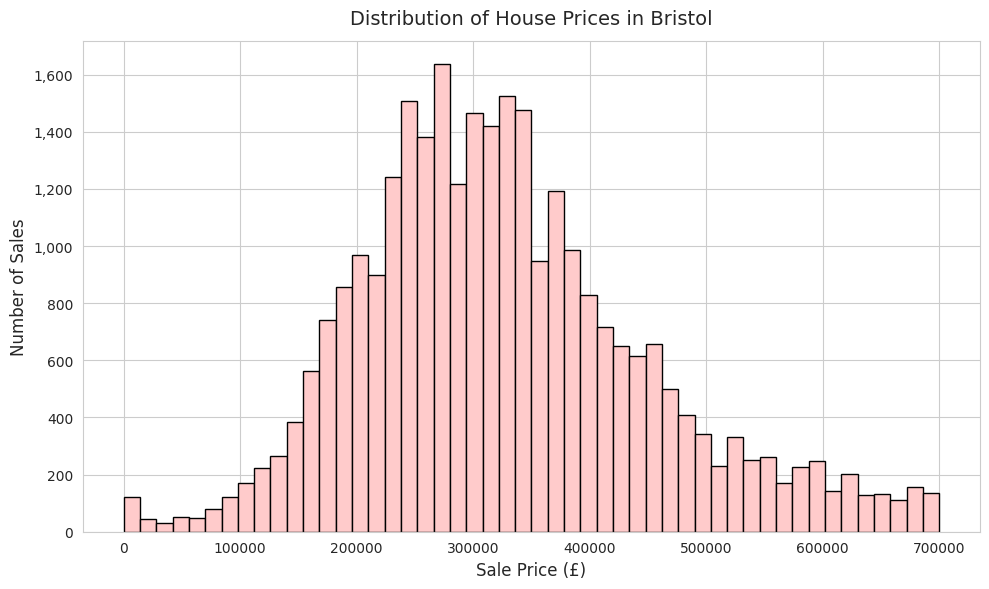

   📩Saved: price_distribution.png
 
 


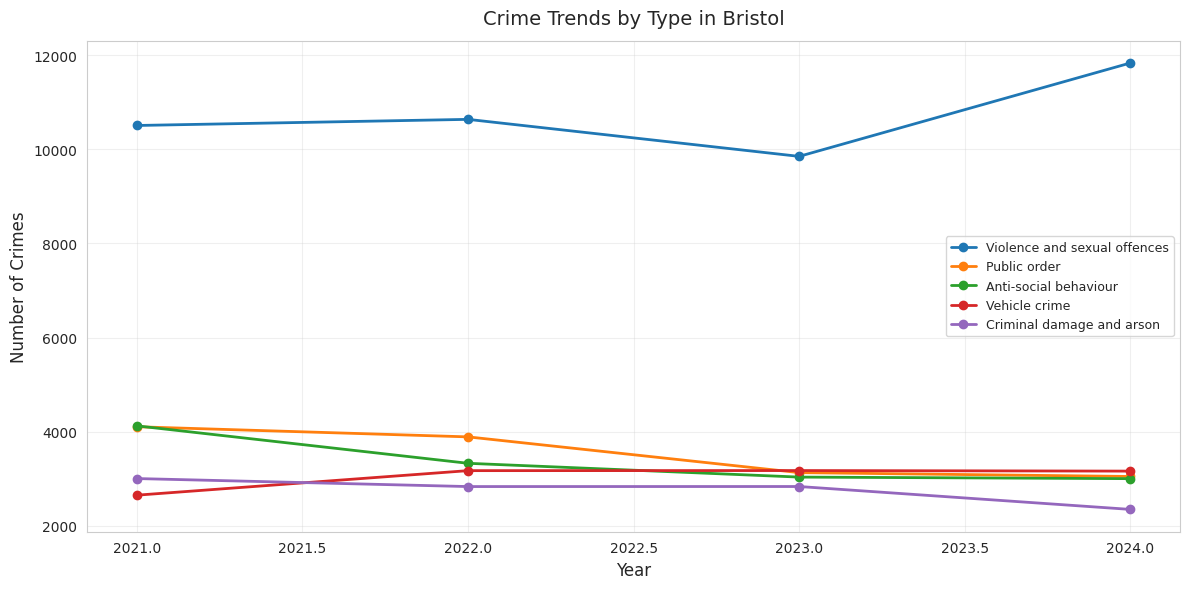

   📩Saved: crime_trends.png
 
 


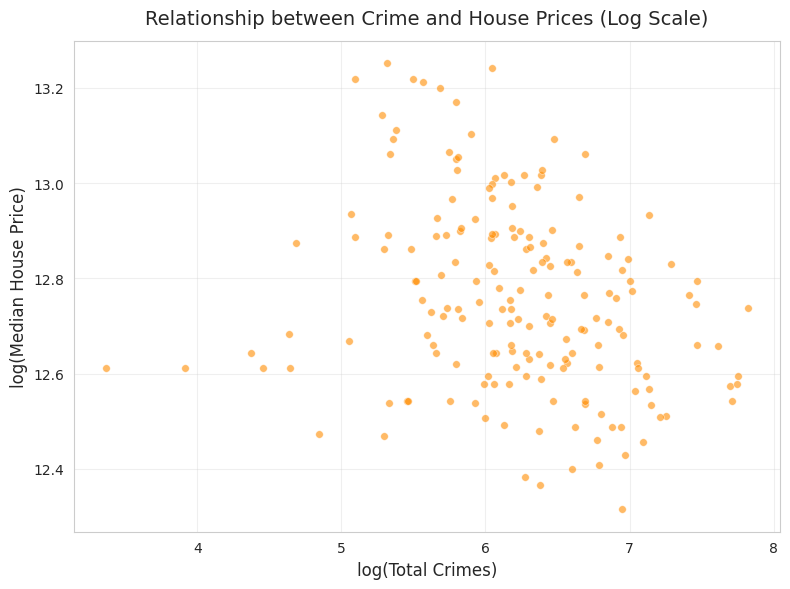

   📩Saved: scatter_crime_price.png
 
 


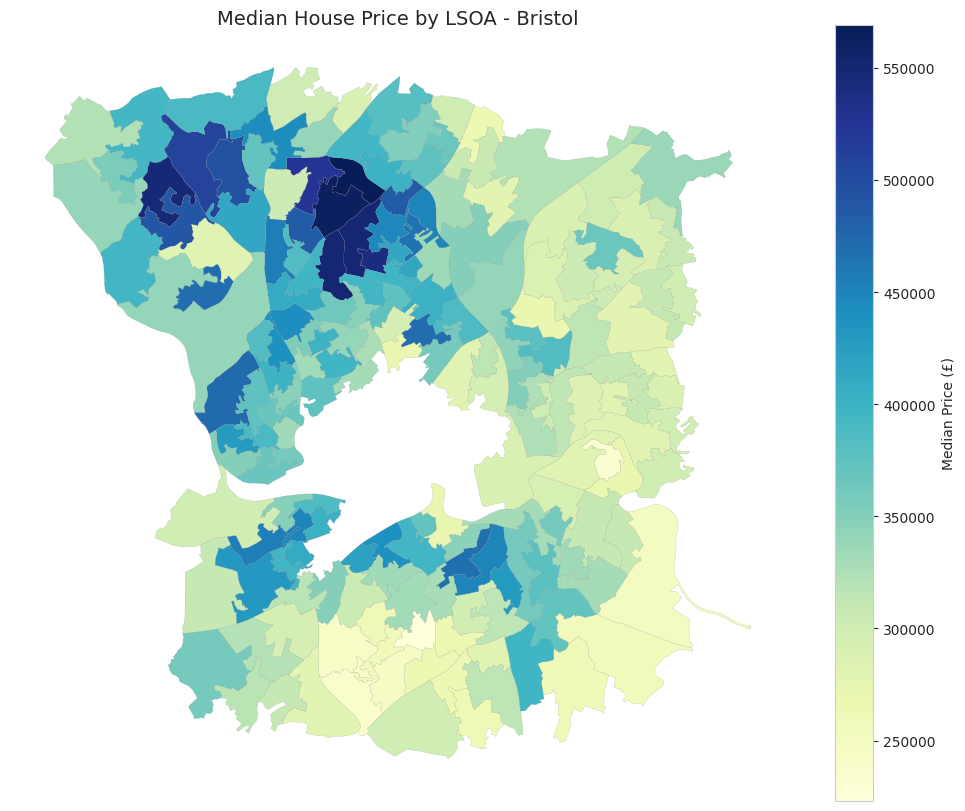

   📩Saved: map_median_price.png
 
 


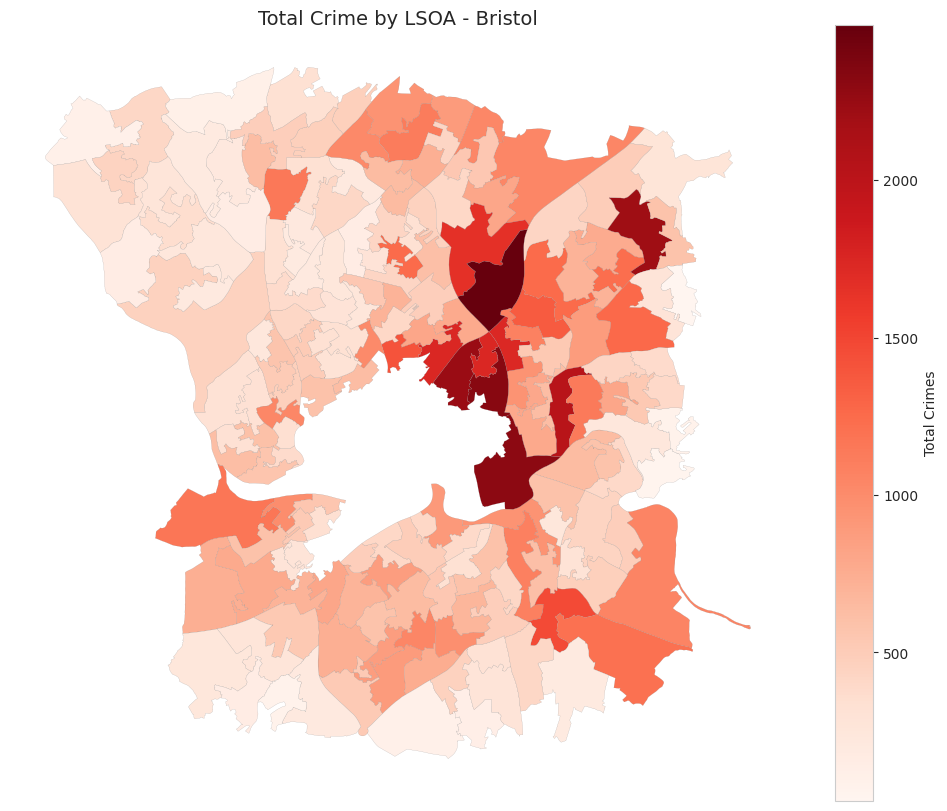

   📩Saved: map_total_crime.png
 
 
 
STEP 5: STATISTICAL TESTING
 
Statistical Testing
 
(1) Correlation Analysis: log(Crime) vs log(Price)
     Pearson r = -0.2565, p = 0.0005  --> Significant
     Spearman ρ = -0.3049, p = 0.0000  --> Significant
(2) Hypothesis Test: High-Crime vs Low-Crime Areas
     H0: Mean log(price) is equal in high and low crime areas
     H1: Mean log(price) differs between high and low crime areas
 
     t-statistic = -4.3901, p-value = 0.0000
Result: REJECT H0 (p < 0.05)
Interpretation: Statistically significant difference in prices
High-crime areas are ~-11.5% lower priced
 
STEP 6: REGRESSION MODELLING
 
 
(1) ORDINARY LEAST SQUARES (OLS) REGRESSION - GLOBAL MODEL

Model: log(price) = β0 + β1·log(crime) + β2·prop_flats + β3·prop_leasehold

Coefficients:
   Intercept:       13.0999
   log(crime):      -0.0644
   prop_flats:      -0.4974
   prop_leasehold:  0.5814

Model Fit:
   R²:              0.1265
   Adjusted R²:     0.1118
   AIC:             -607.97
 

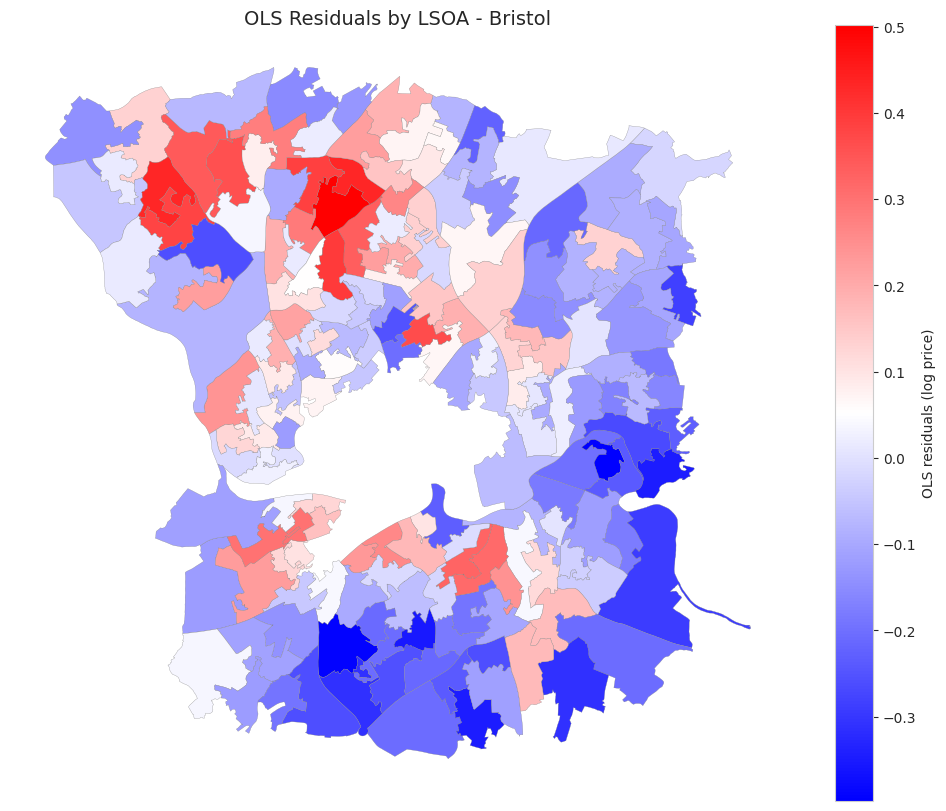

 
   📩Saved OLS residual map: map_ols_residuals.png

 
Calculating Moran's I (spatial autocorrelation)...
     Moran's I:   0.4483
     Expected I:  -0.0055
     p-value:     0.0010
 
(3) GEOGRAPHICALLY WEIGHTED REGRESSION (GWR)
 
Input shape: coords=(182, 2), y=(182, 1), X=(182, 3)
Bandwidth selection...
    Bandwidth: 49.0
Fitting GWR...
Model type                                                         Gaussian
Number of observations:                                                 182
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                              6.169
Log-likelihood:                                                      49.736
AIC:                                                                -91.472
AICc:                                                               -89.131
BIC:                   

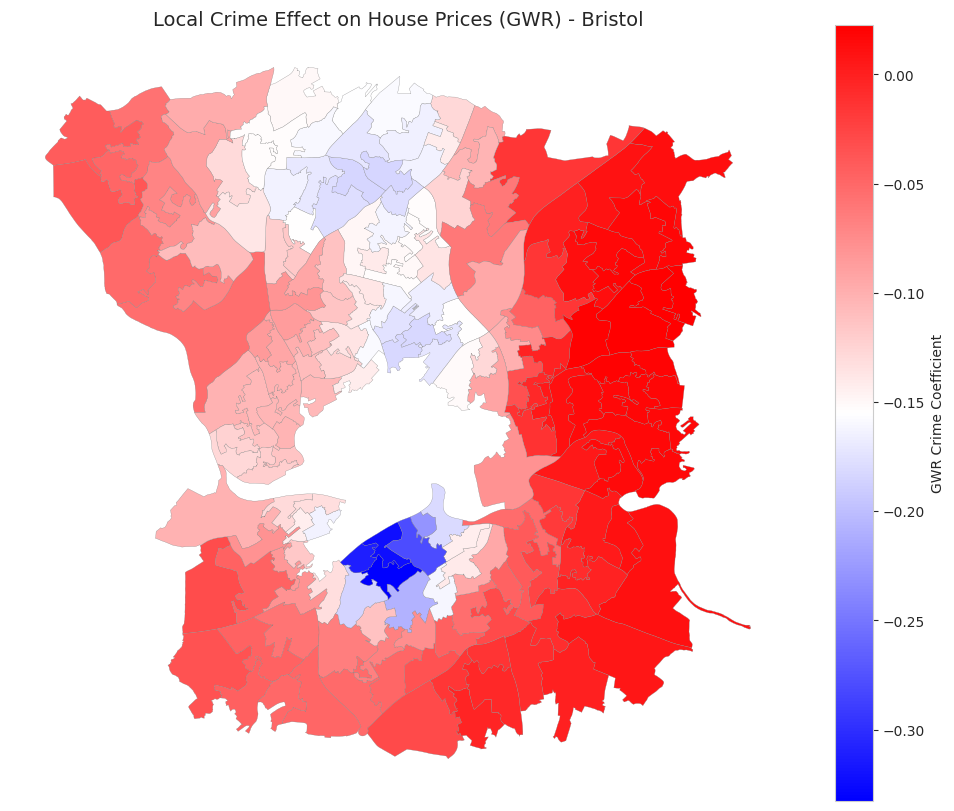

   📩Saved: GWR crime coefficient map
 
 
STEP 9: SAVING RESULTS
model_comparison.csv saved
summary_statistics.json saved
FULL ANALYSIS COMPLETE!
182 LSOAs analyzed

📁 Outputs 
   • All maps & charts (PNG)
   • model_comparison.csv
   • summary.json
   • Clean data (CSV)


In [29]:
results = run_full_analysis()
results['summary_stats']
reg_gdf = results['reg_gdf']

print("\n📁 Outputs ")
print("   • All maps & charts (PNG)")
print("   • model_comparison.csv")
print("   • summary.json")
print("   • Clean data (CSV)")

#Summary statistics

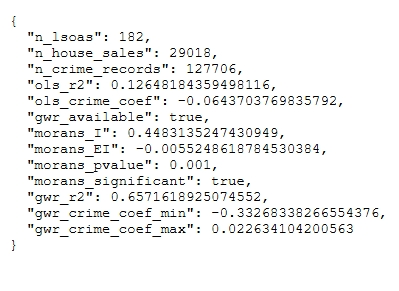

The global OLS model explains only about 12.6% of the variation in log house prices showing a single linear relationship between crime and prices is limited for Bristol. The Moran’s I statistic on the OLS residuals is approximately 0.45 with a p‑value of 0.001, showing strong and statistically significant positive spatial autocorrelation in the errors. So, neighbouring LSOAs tend to have similar prediction errors, suggesting the OLS model violates the independence assumption and misses key spatial patterns in the data.

When I apply Geographically Weighted Regression (GWR), the model fit improves substantially, with an R² of about 0.66. The local crime coefficients range from around −0.33 to +0.02, showing that the effect of crime on prices is not same across the city: in some neighbourhoods higher crime is strongly associated with lower prices, while in others the relationship is weak or slightly positive. This shows GWR highlight the importance of considering local variation in the crime–house price relationship.



# Additional analysis

In [23]:
#ADDITIONAL ANALYSES

# 1. Analyze crime effect by property type
def analyze_by_property_type(reg_gdf):
    """Investigate if crime effect differs by property composition."""
    print("(1) Crime Effect by Property Type Composition")

    # Split LSOAs by flat proportion
    high_flats = reg_gdf[reg_gdf['prop_flats'] > 0.5]
    low_flats = reg_gdf[reg_gdf['prop_flats'] <= 0.5]

    print(f"     High-flat areas (>50% flats): {len(high_flats)} LSOAs")
    print(f"     Mean price: £{high_flats['median_price'].mean():,.0f}")
    print(f"     Mean crimes: {high_flats['total_crimes'].mean():.0f}")

    print(f"     Low-flat areas (≤50% flats): {len(low_flats)} LSOAs")
    print(f"     Mean price: £{low_flats['median_price'].mean():,.0f}")
    print(f"     Mean crimes: {low_flats['total_crimes'].mean():.0f}")


# 2. Identify hotspots and coldspots
def identify_crime_price_hotspots(reg_gdf):
    """Find areas with unusual crime-price combinations."""
    print("(2) Crime-Price Hotspot Analysis")

    # Define thresholds (upper quartile)
    high_crime_threshold = reg_gdf['total_crimes'].quantile(0.75)
    high_price_threshold = reg_gdf['median_price'].quantile(0.75)

    # High crime, high price (unexpected)
    hotspot = reg_gdf[
        (reg_gdf['total_crimes'] > high_crime_threshold) &
        (reg_gdf['median_price'] > high_price_threshold)
    ]

    print(f"     High crime + High price areas: {len(hotspot)} LSOAs")
    if len(hotspot) > 0:
        print("     These areas may have:")
        print("        - City center/commercial locations")
        print("        - High property values despite crime")
        example_code = hotspot.iloc[0]['lsoa_code']
        print(f"    Example LSOA: {example_code}")


In [24]:
analyze_by_property_type(reg_gdf)
identify_crime_price_hotspots(reg_gdf)


(1) Crime Effect by Property Type Composition
     High-flat areas (>50% flats): 37 LSOAs
     Mean price: £367,820
     Mean crimes: 521
     Low-flat areas (≤50% flats): 145 LSOAs
     Mean price: £350,614
     Mean crimes: 666
(2) Crime-Price Hotspot Analysis
     High crime + High price areas: 2 LSOAs
     These areas may have:
        - City center/commercial locations
        - High property values despite crime
    Example LSOA: E01014488


#Crime, property type and hotspots


The descriptive analysis shows that Bristol LSOAs with a higher proportion of flats tend to have slightly higher house prices but lower average crime rates than areas dominated by houses. On average, high‑flat areas (over 50% flats) have a median house price of about £368k and around 521 crimes, while low‑flat areas (50% flats or less) average roughly £351k and 666 crimes. This suggests that denser, flat‑dominated neighbourhoods are not necessarily the most affected by crime, and some suburban, house‑dominated areas experience more incidents.

The hotspot analysis identifies only a few “high crime + high price” neighbourhoods. Just 2 LSOAs are above the upper‑quartile thresholds for both crime and house prices (for example, LSOA E01014488). These locations are likely to be central or mixed‑use areas where strong housing demand keeps prices high despite higher crime levels, showing the relationship between crime and property values varies across the city.